In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import scipy.stats as stats
from catboost import CatBoostRegressor, Pool

In [5]:
url_train = 'https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Datasets/df_train_1_FE.csv'
url_val = 'https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Datasets/df_val_FE_sinLeak.csv'

df = pd.read_csv(url_train, index_col=0)
df_val = pd.read_csv(url_val, index_col=0)

In [ ]:
pd.set_option('display.max_columns', None)

#### Comparacion de bases

In [ ]:
df[['track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name','playlist_name', 'playlist_id']].head(1)

,track_id,track_name,track_artist,track_album_id,track_album_name,playlist_name,playlist_id
Unnamed: 0,,,,,,,
0,RElEdzDz0jD/AyKJjcfulWEzXE0kFpXmh4bXv+Y7ULB1Te...,FiHDRtJEUl5cyhTdIqc96pqUDrUK0HWRLp3DSgTddF8bq1...,brDyePD9ftuUV+4Gnr1FJsWPjK4BxX5b0XyoYraitMs=,bG4siwcYExux98rSemYk4gFXGxfOcnuI4eO5KJWxoMNQqX...,eEEakyxHF5aPFTwo7vH7PSLZS28a22sYpSK+vfnHtVI3oF...,1UeUqIlVAv/WzPy1CR7sm8pQ7buE50YX0hfKcbcxKkw=,R2xsImk7ArHWnrt5W4P7KfkBEFFPXX0SOT12gLJy28ev9t...


In [ ]:
for col in ['track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name','playlist_name', 'playlist_id']:
  display(df[col].apply(len).describe())

,track_id
count,26261.0
mean,64.0
std,0.0
min,64.0
25%,64.0
50%,64.0
75%,64.0
max,64.0


,track_name
count,26261.000000
mean,55.695366
std,16.873269
min,44.000000
25%,44.000000
50%,44.000000
75%,64.000000
max,236.000000


,track_artist
count,26261.000000
mean,45.984844
std,6.189438
min,44.000000
25%,44.000000
50%,44.000000
75%,44.000000
max,128.000000


,track_album_id
count,26261.0
mean,64.0
std,0.0
min,64.0
25%,64.0
50%,64.0
75%,64.0
max,64.0


,track_album_name
count,26261.000000
mean,56.757016
std,17.899464
min,44.000000
25%,44.000000
50%,44.000000
75%,64.000000
max,236.000000


,playlist_name
count,26261.000000
mean,65.605879
std,25.991624
min,44.000000
25%,44.000000
50%,64.000000
75%,64.000000
max,192.000000


,playlist_id
count,26261.0
mean,64.0
std,0.0
min,64.0
25%,64.0
50%,64.0
75%,64.0
max,64.0


In [ ]:
len(set(df['track_id'].values) & set(df_val['track_id'].values))

699

In [ ]:
len(set(df['track_name'].values) & set(df_val['track_name'].values))

1327

In [ ]:
len(set(df['track_artist'].values) & set(df_val['track_artist'].values))

861

In [ ]:
len(set(df['track_album_id'].values) & set(df_val['track_album_id'].values))

784

In [ ]:
len(set(df['track_album_name'].values) & set(df_val['track_album_name'].values))

1192

Los datos de las playlist no aparecen en el val set

In [ ]:
len(set(df['playlist_name'].values) & set(df_val['playlist_name'].values))

3

In [ ]:
len(set(df['playlist_id'].values) & set(df_val['playlist_id'].values))

3

Vemos de armar un dataset solo con los valores coincidentes con la variables de val

In [ ]:
condicion1 = (df['track_album_name'].isin(set(df['track_album_name'].values) & set(df_val['track_album_name'].values)))

condicion2 = (df['track_album_id'].isin(set(df['track_album_id'].values) & set(df_val['track_album_id'].values)))

condicion3 = (df['track_artist'].isin(set(df['track_artist'].values) & set(df_val['track_artist'].values)))

condicion4 = (df['track_name'].isin(set(df['track_name'].values) & set(df_val['track_name'].values)))

condicion5 = (df['track_id'].isin(set(df['track_id'].values) & set(df_val['track_id'].values)))

In [ ]:
condicion6 = ((df['playlist_genre'] == 'r&b') | (df['playlist_subgenre'] == 'neo soul'))

In [ ]:
shape_orig = df.shape[0]
shape_modificado = df[condicion1 | condicion2 | condicion3 | condicion4 | condicion5 | condicion6].shape[0]

print(f'Dataset original: {shape_orig} filas')
print(f'Dataset coincidente con val set: {shape_modificado} filas')

Dataset original: 26261 filas
Dataset coincidente con val set: 10848 filas


### Particion de datos

Sacamos nulos

In [ ]:
df.dropna(inplace=True)

In [ ]:
continuas = ['danceability', 'energy',
       'loudness', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'distance_mean_danceability',
       'distance_sq_mean_danceability', 'distance_mean_energy',
       'distance_sq_mean_energy', 'distance_mean_loudness',
       'distance_sq_mean_loudness', 'distance_mean_speechiness',
       'distance_sq_mean_speechiness', 'distance_mean_acousticness',
       'distance_sq_mean_acousticness', 'distance_mean_liveness',
       'distance_sq_mean_liveness', 'distance_mean_valence',
       'distance_sq_mean_valence', 'distance_mean_tempo',
       'distance_sq_mean_tempo', 'distance_mean_duration_ms',
       'distance_sq_mean_duration_ms', 'dance_energy', 'happy_energy',
       'acoustic_instr', 'duration_min', 'track_age']
categoricas = ['playlist_genre', 'playlist_subgenre', 'grupo_anio', 'track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name']
otras = ['key', 'mode']

X = df[continuas+categoricas+otras].copy()
y = df['track_popularity'].copy()

In [ ]:
df['key'] = df['key'].astype(str)
df['mode'] = df['mode'].astype(str)
df['grupo_anio'] = df['grupo_anio'].astype(str)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
cat_features = categoricas.copy() + otras.copy()
cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_features]

### CatBoost

#### Zero: all variables

Entrenamos un modelo simple sin las categoricas de playlist y track names -> SIN variables de Feature Engineering

In [ ]:
# X_train_inic = X_train.drop(columns=['playlist_genre', 'playlist_subgenre', 'track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name'])
# X_test_inic = X_test.drop(columns=['playlist_genre', 'playlist_subgenre', 'track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name'])

# train_pool = Pool(X_train_inic, y_train, cat_features=list(X_train_inic.select_dtypes(include='object').columns))
# test_pool  = Pool(X_test_inic,  y_test,  cat_features=list(X_test_inic.select_dtypes(include='object').columns))

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

In [ ]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.025,
    loss_function='RMSE',
    eval_metric='RMSE',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
model.fit(train_pool, eval_set=test_pool)

print('TRAIN')
y_pred = model.predict(X_train)
print(f"R²:   {r2_score(y_train, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred)):.4f}")

print('TEST')
y_pred = model.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

0:	learn: 24.7691156	test: 24.7896553	best: 24.7896553 (0)	total: 179ms	remaining: 2m 58s
100:	learn: 19.1849324	test: 18.0452727	best: 18.0452727 (100)	total: 6.07s	remaining: 54s
200:	learn: 18.6872631	test: 17.6364070	best: 17.6364070 (200)	total: 13.1s	remaining: 52.2s
300:	learn: 18.3946245	test: 17.4653433	best: 17.4644803 (299)	total: 19.9s	remaining: 46.2s
400:	learn: 18.1840103	test: 17.3810212	best: 17.3810212 (400)	total: 27.8s	remaining: 41.6s
500:	learn: 18.0033619	test: 17.3281423	best: 17.3281423 (500)	total: 34.6s	remaining: 34.5s
600:	learn: 17.8356687	test: 17.2678646	best: 17.2678646 (600)	total: 42.6s	remaining: 28.3s
700:	learn: 17.6803732	test: 17.2249188	best: 17.2249188 (700)	total: 49.6s	remaining: 21.1s
800:	learn: 17.5536224	test: 17.1914004	best: 17.1911833 (797)	total: 58s	remaining: 14.4s
900:	learn: 17.4300868	test: 17.1677769	best: 17.1672770 (896)	total: 1m 5s	remaining: 7.25s
999:	learn: 17.3187675	test: 17.1491000	best: 17.1491000 (999)	total: 1m 13s	

#### Submission 1 -> Kaggle R^2: 0,32437

In [ ]:
df_val_ML = df_val[continuas+categoricas+otras]
df_val_ML['key'] = df_val_ML['key'].astype(str)
df_val_ML['mode'] = df_val_ML['mode'].astype(str)
df_val_ML['grupo_anio'] = df_val_ML['grupo_anio'].astype(str)

/tmp/ipykernel_3155/1318439828.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val_ML['key'] = df_val_ML['key'].astype(str)
/tmp/ipykernel_3155/1318439828.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val_ML['mode'] = df_val_ML['mode'].astype(str)
/tmp/ipykernel_3155/1318439828.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.or

In [ ]:
y_pred_val = model.predict(df_val_ML)

In [ ]:
submission_df_cb = pd.DataFrame({
    'ID': list(df_val.index),
    'track_popularity': y_pred_val
})

submission_df_cb.to_csv('submission_catboost0.csv', index=False)

#### Second: sin playlist_genre y subgenre, y solo canciones con

In [ ]:
df_mod = df[condicion1 | condicion2 | condicion3 | condicion4 | condicion5 | condicion6].copy()

In [ ]:
df_mod['key'] = df_mod['key'].astype(str)
df_mod['mode'] = df_mod['mode'].astype(str)
df_mod['grupo_anio'] = df_mod['grupo_anio'].astype(str)

In [ ]:
X_mod = df_mod[continuas+categoricas+otras].copy()
y_mod = df_mod['track_popularity'].copy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_mod, y_mod, test_size=0.1, random_state=42)

In [ ]:
train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

In [ ]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.025,
    loss_function='RMSE',
    eval_metric='RMSE',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
model.fit(train_pool, eval_set=test_pool)

print('TRAIN')
y_pred = model.predict(X_train)
print(f"R²:   {r2_score(y_train, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred)):.4f}")

print('TEST')
y_pred = model.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

0:	learn: 26.2015102	test: 25.8499678	best: 25.8499678 (0)	total: 46.6ms	remaining: 23.3s
100:	learn: 19.1463437	test: 18.2871756	best: 18.2871756 (100)	total: 4.34s	remaining: 17.1s
200:	learn: 18.4412395	test: 17.9529221	best: 17.9529221 (200)	total: 9.47s	remaining: 14.1s
300:	learn: 18.1078104	test: 17.8106406	best: 17.8106406 (300)	total: 13s	remaining: 8.61s
400:	learn: 17.8315215	test: 17.7305702	best: 17.7297143 (399)	total: 16.7s	remaining: 4.12s
499:	learn: 17.5551603	test: 17.6870388	best: 17.6867854 (498)	total: 21.4s	remaining: 0us

bestTest = 17.68678543
bestIteration = 498

Shrink model to first 499 iterations.
TRAIN
R²:   0.7780
RMSE: 12.4609
TEST
R²:   0.5423
RMSE: 17.6868


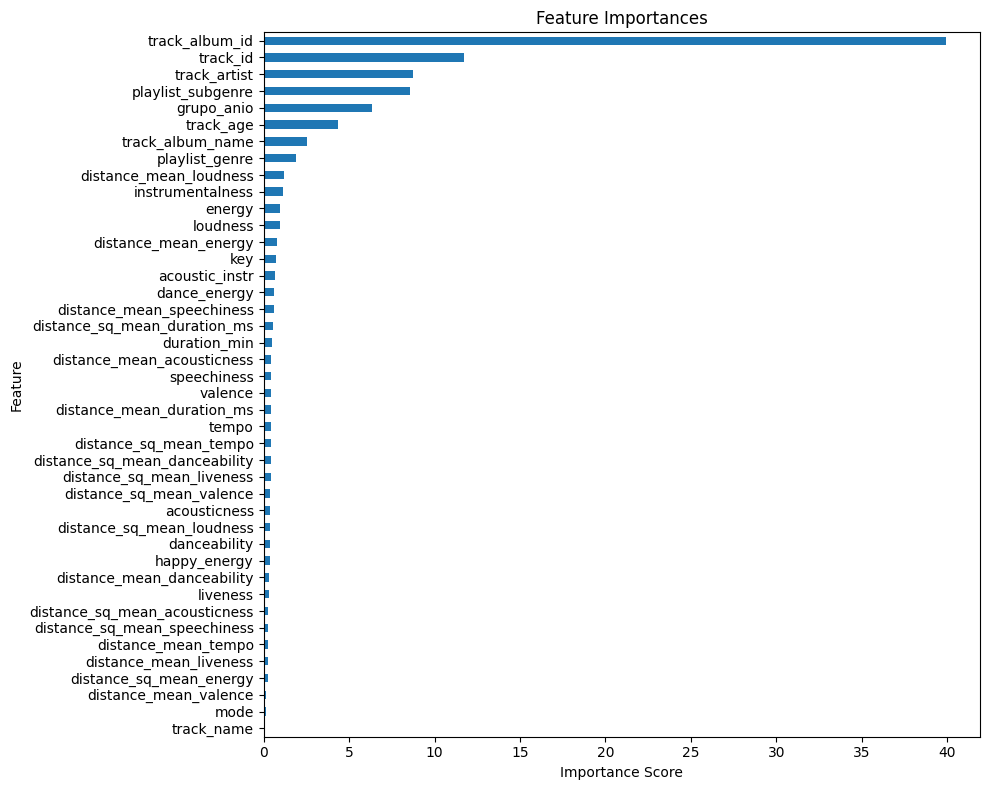

In [ ]:
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)

plt.figure(figsize=(10, 8))
feature_importances.sort_values(ascending=True).plot(kind='barh')
plt.title('Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### Submission 2 -> Kaggle test: 0,23031

In [ ]:
y_pred_val_reduced = model.predict(df_val_ML)

In [ ]:
submission_df_cb = pd.DataFrame({
    'ID': list(df_val.index),
    'track_popularity': y_pred_val_reduced
})

submission_df_cb.to_csv('submission_catboost1_reduced.csv', index=False)

#### Submission 3: Kaggle test -> 0,32117

In [ ]:
submission_df_cb_bis = submission_df_cb.copy()
submission_df_cb_bis['track_popularity'] = submission_df_cb['track_popularity'] - 4
submission_df_cb_bis.loc[submission_df_cb_bis['track_popularity'] < 0, 'track_popularity'] = 2
submission_df_cb_bis.to_csv('submission_catboost1_reduced_inventada.csv', index=False)

A posteriori puede ser que evitar predicciones en 0 sea una mala idea

### Feat Eng

In [6]:
df = pd.read_csv(url_train, index_col=0)

In [7]:
# Cantidad de caracteres del playlist_name
df['len_playlist_name'] = df['playlist_name'].apply(len)

# Distribuciones muy skewed que se benefician del log
df['log_duration_ms']       = np.log1p(df['duration_ms'])
df['log_instrumentalness']  = np.log1p(df['instrumentalness'])
df['log_speechiness']       = np.log1p(df['speechiness'])
df['log_liveness']          = np.log1p(df['liveness'])
# Estas tres suelen tener cola larga hacia valores bajos
# log1p evita problemas con valores en 0

In [8]:
audio_features = ['danceability', 'energy', 'loudness',
                  'tempo', 'valence', 'acousticness',
                  'instrumentalness', 'speechiness', 'duration_ms']
# Z-score global (sin agrupamiento)
for col in audio_features:
    mean = df[col].mean()
    std  = df[col].std()
    df[f'z_{col}'] = (df[col] - mean) / std

# Rareza total: qué tan lejos está del "sonido promedio global"
z_cols = [f'z_{c}' for c in audio_features]
df['global_atipicality']    = np.sqrt((df[z_cols] ** 2).sum(axis=1))

# Rareza máxima: en qué feature es más extrema la canción
df['max_z_score'] = df[z_cols].abs().max(axis=1)

# En qué dimensión es más rara (puede capturar "tipo de rareza")
df['most_extreme_feature'] = df[z_cols].abs().idxmax(axis=1)

In [9]:
# ── Mood y atmósfera ───────────────────────────────────────────
df['mood_score']         = df['valence'] * df['danceability'] * df['energy']
df['chill_score']        = df['acousticness'] * (1 - df['energy']) * df['valence']  # relajada y positiva
df['melancholy_score']   = (1 - df['valence']) * df['acousticness']  # triste y acústica

# ── Radio-friendliness ─────────────────────────────────────────
df['radio_friendly']     = df['energy'] * (1 - df['instrumentalness']) * (1 - df['speechiness'])
df['club_score']         = df['danceability'] * df['energy'] * (1 - df['acousticness'])

# ── Contraste y tensión ────────────────────────────────────────
df['acoustic_contrast']  = np.abs(df['acousticness'] - df['energy'])
df['mood_complexity']    = np.abs(df['valence'] - df['energy'])      # canciones "raras" emocionalmente
df['dance_val_tension']  = np.abs(df['danceability'] - df['valence'])# bailable pero triste, o alegre pero no bailable

# ── Características de voz ─────────────────────────────────────
df['vocal_presence']     = df['speechiness'] * (1 - df['instrumentalness'])
df['pure_instrumental']  = df['instrumentalness'] * (1 - df['speechiness'])
df['spoken_word']        = df['speechiness'] * (1 - df['danceability'])  # rap/podcast vs canción

# Loudness está en dB (negativo). Más cerca de 0 = más fuerte (más masterizado)
df['loudness_abs'] = np.abs(df['loudness'])  # versión positiva más intuitiva
df['loudness_energy_ratio'] = df['loudness_abs'] / (df['energy'] + 1e-6)  # compresión relativa

# Canciones muy comprimidas (loud + alta energía) → típico del pop moderno
df['dynamic_compression'] = df['energy'] / df['loudness_abs'].replace(0, 1e-6)

# Liveness alta + instrumentalness baja = grabación en vivo con voz
df['live_vocal'] = df['liveness'] * (1 - df['instrumentalness'])

# "Pureza" de estudio: baja liveness + baja speechiness
df['studio_clean'] = (1 - df['liveness']) * (1 - df['speechiness'])

In [10]:
# Términos cuadráticos de las más relevantes
# (la popularidad puede tener relación no lineal con estas)
for col in ['danceability', 'energy', 'valence', 'loudness_abs']:
    df[f'{col}_sq']   = df[col] ** 2
    df[f'{col}_sqrt'] = np.sqrt(np.abs(df[col]))

In [11]:
df['tonality'] = df['key'].astype(str) + '_' + df['mode'].astype(str)

In [12]:
df.to_csv('df_train_2_FE.csv')

Hacemos lo mismo para val set

In [13]:
df_val = pd.read_csv(url_val, index_col=0)

In [14]:
# Cantidad de caracteres del playlist_name
df_val['len_playlist_name'] = df_val['playlist_name'].apply(len)

# Distribuciones muy skewed que se benefician del log
df_val['log_duration_ms']       = np.log1p(df_val['duration_ms'])
df_val['log_instrumentalness']  = np.log1p(df_val['instrumentalness'])
df_val['log_speechiness']       = np.log1p(df_val['speechiness'])
df_val['log_liveness']          = np.log1p(df_val['liveness'])
# Estas tres suelen tener cola larga hacia valores bajos
# log1p evita problemas con valores en 0

In [15]:
audio_features = ['danceability', 'energy', 'loudness',
                  'tempo', 'valence', 'acousticness',
                  'instrumentalness', 'speechiness', 'duration_ms']
# Z-score global (sin agrupamiento)
for col in audio_features:
    mean = df[col].mean()
    std  = df[col].std()
    df_val[f'z_{col}'] = (df_val[col] - mean) / std

# Rareza total: qué tan lejos está del "sonido promedio global"
z_cols = [f'z_{c}' for c in audio_features]
df_val['global_atipicality']    = np.sqrt((df_val[z_cols] ** 2).sum(axis=1))

# Rareza máxima: en qué feature es más extrema la canción
df_val['max_z_score'] = df_val[z_cols].abs().max(axis=1)

# En qué dimensión es más rara (puede capturar "tipo de rareza")
df_val['most_extreme_feature'] = df_val[z_cols].abs().idxmax(axis=1)

In [16]:
# ── Mood y atmósfera ───────────────────────────────────────────
df_val['mood_score']         = df_val['valence'] * df_val['danceability'] * df_val['energy']
df_val['chill_score']        = df_val['acousticness'] * (1 - df_val['energy']) * df_val['valence']  # relajada y positiva
df_val['melancholy_score']   = (1 - df_val['valence']) * df_val['acousticness']  # triste y acústica

# ── Radio-friendliness ─────────────────────────────────────────
df_val['radio_friendly']     = df_val['energy'] * (1 - df_val['instrumentalness']) * (1 - df_val['speechiness'])
df_val['club_score']         = df_val['danceability'] * df_val['energy'] * (1 - df_val['acousticness'])

# ── Contraste y tensión ────────────────────────────────────────
df_val['acoustic_contrast']  = np.abs(df_val['acousticness'] - df_val['energy'])
df_val['mood_complexity']    = np.abs(df_val['valence'] - df_val['energy'])      # canciones "raras" emocionalmente
df_val['dance_val_tension']  = np.abs(df_val['danceability'] - df_val['valence'])# bailable pero triste, o alegre pero no bailable

# ── Características de voz ─────────────────────────────────────
df_val['vocal_presence']     = df_val['speechiness'] * (1 - df_val['instrumentalness'])
df_val['pure_instrumental']  = df_val['instrumentalness'] * (1 - df_val['speechiness'])
df_val['spoken_word']        = df_val['speechiness'] * (1 - df_val['danceability'])  # rap/podcast vs canción

# Loudness está en dB (negativo). Más cerca de 0 = más fuerte (más masterizado)
df_val['loudness_abs'] = np.abs(df_val['loudness'])  # versión positiva más intuitiva
df_val['loudness_energy_ratio'] = df_val['loudness_abs'] / (df_val['energy'] + 1e-6)  # compresión relativa

# Canciones muy comprimidas (loud + alta energía) → típico del pop moderno
df_val['dynamic_compression'] = df_val['energy'] / df_val['loudness_abs'].replace(0, 1e-6)

# Liveness alta + instrumentalness baja = grabación en vivo con voz
df_val['live_vocal'] = df_val['liveness'] * (1 - df_val['instrumentalness'])

# "Pureza" de estudio: baja liveness + baja speechiness
df_val['studio_clean'] = (1 - df_val['liveness']) * (1 - df_val['speechiness'])

In [17]:
# Términos cuadráticos de las más relevantes
# (la popularidad puede tener relación no lineal con estas)
for col in ['danceability', 'energy', 'valence', 'loudness_abs']:
    df_val[f'{col}_sq']   = df_val[col] ** 2
    df_val[f'{col}_sqrt'] = np.sqrt(np.abs(df_val[col]))

In [18]:
df_val['tonality'] = df_val['key'].astype(str) + '_' + df_val['mode'].astype(str)

In [19]:
df_val.to_csv('df_val_2_FE_sinLeak.csv')

### Particion de datos 2

Sacamos nulos

In [ ]:
df.dropna(inplace=True)

In [ ]:
continuas = list(df.select_dtypes(include='float').columns) + ['track_age', 'len_playlist_name']
categoricas = ['playlist_genre', 'playlist_subgenre', 'grupo_anio', 'track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name']
otras = ['key', 'mode','tonality','most_extreme_feature']

X = df[continuas+categoricas+otras].copy()
y = df['track_popularity'].copy()

In [ ]:
df['key'] = df['key'].astype(str)
df['mode'] = df['mode'].astype(str)
df['grupo_anio'] = df['grupo_anio'].astype(str)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
cat_features = categoricas.copy() + otras.copy()
cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_features]

### CatBoost 2

#### Optimizacion CatBoost

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

X_sample, _, y_sample, _ = train_test_split(X_train, y_train, train_size=0.3, random_state=42)

# ── Encodear categóricas solo para la búsqueda ────────────────
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_enc = X_train.copy()
X_sample_enc = X_sample.copy()
X_train_enc[cat_features]  = oe.fit_transform(X_train[cat_features])
X_sample_enc[cat_features] = oe.transform(X_sample[cat_features])

param_space_1 = {
    'iterations':    Integer(100, 400),   # techo más bajo
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'depth':         Integer(3, 8),       # profundidad razonable, no 15
    'subsample':     Real(0.5, 1.0),
}

cb = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=0
)

search_1 = BayesSearchCV(
    cb,
    param_space_1,
    n_iter=10,
    cv=KFold(n_splits=3, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',
    n_jobs=1,        # ← cambiá a 1, el paralelismo a veces enlentece CatBoost
    random_state=42,
    verbose=1
)

search_1.fit(X_sample_enc, y_sample)  # datos encodeados, sin cat_features

print("=== PASO 1 — mejores parámetros (muestra) ===")
print(search_1.best_params_)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
=== PASO 1 — mejores parámetros (muestra) ===
OrderedDict({'depth': 7, 'iterations': 231, 'learning_rate': 0.05996280567850356, 'subsample': 0.8578566310535165})


OrderedDict({'depth': 7, 'iterations': 231, 'learning_rate': 0.05996280567850356, 'subsample': 0.8578566310535165})


In [ ]:
# ── Modelo final con Pool y categóricas reales ─────────────────
# Acá sí aprovechás el encoding nativo de CatBoost
final_model = CatBoostRegressor(
    **search_1.best_params_,
    loss_function='RMSE',
    eval_metric='RMSE',
    early_stopping_rounds=30,
    random_seed=42,
    verbose=50
)
final_model.fit(train_pool, eval_set=test_pool)  # Pool con cat_features reales

0:	learn: 24.4993471	test: 24.4265106	best: 24.4265106 (0)	total: 156ms	remaining: 35.9s
50:	learn: 18.9011926	test: 17.8898987	best: 17.8898987 (50)	total: 6.35s	remaining: 22.4s
100:	learn: 18.3361448	test: 17.5163282	best: 17.5163282 (100)	total: 14.8s	remaining: 19s
150:	learn: 17.9725127	test: 17.3509455	best: 17.3488495 (148)	total: 22.2s	remaining: 11.8s
200:	learn: 17.6341222	test: 17.2094073	best: 17.2094073 (200)	total: 30.1s	remaining: 4.5s
230:	learn: 17.4469951	test: 17.1495051	best: 17.1490467 (229)	total: 34.6s	remaining: 0us

bestTest = 17.14904668
bestIteration = 229

Shrink model to first 230 iterations.


CatBoostRegressor(depth=7, early_stopping_rounds=30, eval_metric='RMSE', iterations=231, learning_rate=0.05996280567850356, loss_function='RMSE', random_seed=42, subsample=0.8578566310535165, verbose=50)


=== MÉTRICAS EN TEST SET ===
R²:   0.5316
RMSE: 17.1490


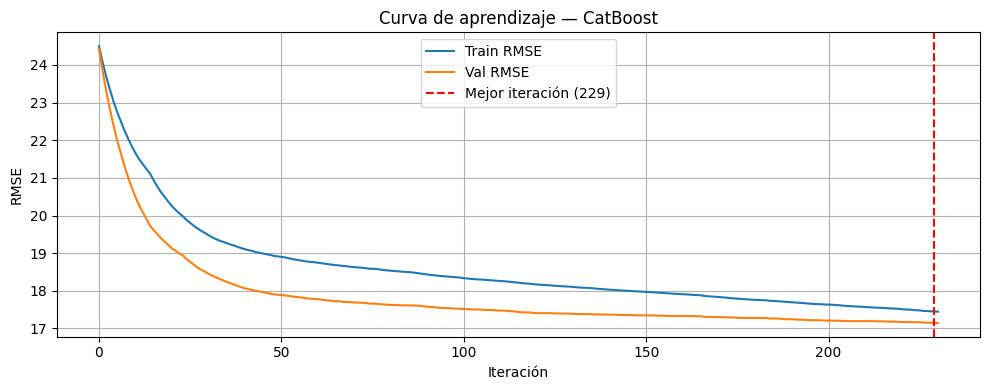

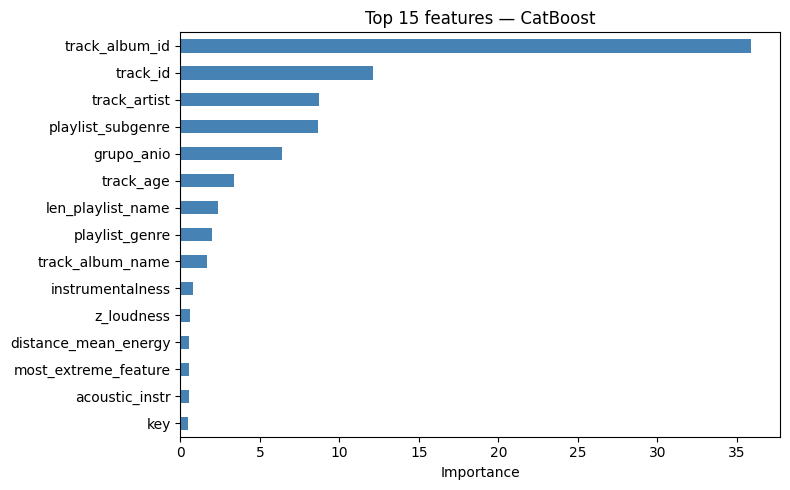

In [ ]:
# ── 6. EVALUACIÓN FINAL ───────────────────────────────────────
y_pred = final_model.predict(X_test)

print("\n=== MÉTRICAS EN TEST SET ===")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

evals = final_model.get_evals_result()
plt.figure(figsize=(10, 4))
plt.plot(evals['learn']['RMSE'],      label='Train RMSE')
plt.plot(evals['validation']['RMSE'], label='Val RMSE')
plt.axvline(final_model.best_iteration_, color='red', linestyle='--',
            label=f'Mejor iteración ({final_model.best_iteration_})')
plt.xlabel('Iteración')
plt.ylabel('RMSE')
plt.title('Curva de aprendizaje — CatBoost')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('catboost_learning_curve.png', dpi=150)
plt.show()

# ── 8. FEATURE IMPORTANCE ─────────────────────────────────────
fi = pd.Series(
    final_model.get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
fi.tail(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 features — CatBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('catboost_feature_importance.png', dpi=150)
plt.show()

# ── 9. GUARDAR MODELO ─────────────────────────────────────────
final_model.save_model('catboost_regressor.cbm')
# Para cargar:
# model = CatBoostRegressor()
# model.load_model('catboost_regressor.cbm')

In [ ]:
pd.DataFrame(fi.sort_values(ascending=False)).T

,track_album_id,track_id,track_artist,playlist_subgenre,grupo_anio,track_age,len_playlist_name,playlist_genre,track_album_name,instrumentalness,z_loudness,distance_mean_energy,most_extreme_feature,acoustic_instr,key,spoken_word,track_name,pure_instrumental,loudness,energy,loudness_abs,distance_mean_loudness,z_instrumentalness,duration_min,distance_sq_mean_valence,z_energy,energy_sq,radio_friendly,distance_mean_duration_ms,log_instrumentalness,distance_sq_mean_energy,live_vocal,distance_mean_acousticness,distance_mean_tempo,z_tempo,z_speechiness,z_valence,tonality,loudness_abs_sq,danceability_sqrt,energy_sqrt,chill_score,melancholy_score,max_z_score,distance_sq_mean_duration_ms,distance_sq_mean_loudness,dance_val_tension,studio_clean,distance_sq_mean_liveness,z_acousticness,z_danceability,dance_energy,distance_mean_valence,tempo,valence,speechiness,vocal_presence,loudness_abs_sqrt,distance_mean_liveness,distance_mean_speechiness,log_duration_ms,danceability_sq,global_atipicality,happy_energy,liveness,acousticness,distance_sq_mean_tempo,log_speechiness,acoustic_contrast,log_liveness,distance_mean_danceability,distance_sq_mean_danceability,mode,danceability,valence_sqrt,duration_ms,distance_sq_mean_acousticness,dynamic_compression,club_score,mood_score,z_duration_ms,loudness_energy_ratio,mood_complexity,distance_sq_mean_speechiness,valence_sq
0,35.919491,12.10202,8.749042,8.680976,6.398557,3.399053,2.38996,2.022038,1.692689,0.807538,0.596332,0.541501,0.529797,0.527936,0.496364,0.491092,0.455767,0.446754,0.413117,0.371058,0.355907,0.353552,0.348218,0.343912,0.333944,0.324164,0.317234,0.300128,0.287696,0.282958,0.268313,0.265158,0.262158,0.261705,0.260035,0.258037,0.25553,0.246679,0.246515,0.246329,0.242799,0.242131,0.242016,0.232362,0.229923,0.227929,0.213926,0.213754,0.211419,0.210652,0.210573,0.209035,0.208067,0.206713,0.202295,0.199678,0.192089,0.184265,0.180627,0.176976,0.175061,0.162952,0.160402,0.15486,0.151128,0.148378,0.145203,0.144741,0.140793,0.135609,0.135142,0.131038,0.128871,0.118708,0.115702,0.111219,0.108209,0.107247,0.092811,0.089078,0.076202,0.059022,0.055653,0.03624,0.029249


In [ ]:
fi = fi.sort_values(ascending=False)

In [ ]:
total = fi.sum()
fi_pct = (fi / total * 100).round(3)

# Cuántas features necesitás para cubrir el 95% de la importancia
fi_pct_cumsum = fi_pct.cumsum()
n_features_95 = (fi_pct_cumsum < 95).sum()
print(f"Features para cubrir 95% de importancia: {n_features_95}")

Features para cubrir 95% de importancia: 49


In [ ]:
X_train.shape[1]

85

#### Nueva division sets

In [ ]:
# Tenemos X_train y X_test
# Dividimos X_train en X_train_dev y X_train_val

# Primero separás un test local que no tocás hasta el final
X_train_dev, X_train_val, y_train_dev, y_train_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

Correos un modelo pesado en todo el dataset

In [ ]:
cb2 = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    early_stopping_rounds=200,
    random_seed=42,
    verbose=500,
    iterations=2000,
    learning_rate=0.01,
    depth=5
)

cb2.fit(X_train_dev, y_train_dev, eval_set=(X_train_val, y_train_val), cat_features=cat_features)

0:	learn: 24.9811453	test: 24.6417025	best: 24.6417025 (0)	total: 112ms	remaining: 3m 44s
500:	learn: 19.1315744	test: 18.2189947	best: 18.2189947 (500)	total: 33.9s	remaining: 1m 41s
1000:	learn: 18.6617241	test: 17.9602556	best: 17.9598368 (989)	total: 1m 10s	remaining: 1m 10s
1500:	learn: 18.3292036	test: 17.8298305	best: 17.8295662 (1496)	total: 1m 46s	remaining: 35.3s
1999:	learn: 18.0910075	test: 17.7855260	best: 17.7852848 (1998)	total: 2m 23s	remaining: 0us

bestTest = 17.78528479
bestIteration = 1998

Shrink model to first 1999 iterations.


CatBoostRegressor(depth=5, early_stopping_rounds=200, eval_metric='RMSE', iterations=2000, learning_rate=0.01, loss_function='RMSE', random_seed=42, verbose=500)

In [ ]:
print("\n=== MÉTRICAS EN TRAIN SET ===")
y_pred_train_dev = cb2.predict(X_train_dev)
print(f"R²:   {r2_score(y_train, y_pred_train):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")

print("\n=== MÉTRICAS EN VAL SET ===")
y_pred_train_val = cb2.predict(X_train_val)
print(f"R²:   {r2_score(y_train_val, y_pred_train_val):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train_val, y_pred_train_val)):.4f}")

print("\n=== MÉTRICAS EN TEST SET ===")
y_pred_test = cb2.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred_test):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")


=== MÉTRICAS EN TRAIN SET ===
R²:   0.7905
RMSE: 11.4296

=== MÉTRICAS EN VAL SET ===
R²:   0.4799
RMSE: 17.7853

=== MÉTRICAS EN TEST SET ===
R²:   0.4900
RMSE: 17.8953


In [ ]:
fi_modelo_pesado = pd.DataFrame(pd.Series(cb2.get_feature_importance(),index=X_train.columns).sort_values(ascending=False))

In [ ]:
total2 = fi_modelo_pesado.sum()
fi_modelo_pesado_pct = (fi_modelo_pesado / total2 * 100).round(3)

# Cuántas features necesitás para cubrir el 95% de la importancia
fi_modelo_pesado_pct_cumsum = fi_modelo_pesado_pct.cumsum()
n_features_95_2 = (fi_modelo_pesado_pct_cumsum < 95).sum()
print(f"Features para cubrir 95% de importancia: {n_features_95_2.values[0]}")

Features para cubrir 95% de importancia: 47


#### Submission 4

In [ ]:
y_pred_cb2 = cb2.predict(df_val[list(X_train_dev.columns)])

In [ ]:
submission_df_cb = pd.DataFrame({
    'ID': list(df_val.index),
    'track_popularity': y_pred_cb2
})

submission_df_cb.to_csv('submission_catboost2_FE.csv', index=False)

<Axes: xlabel='track_popularity', ylabel='Density'>

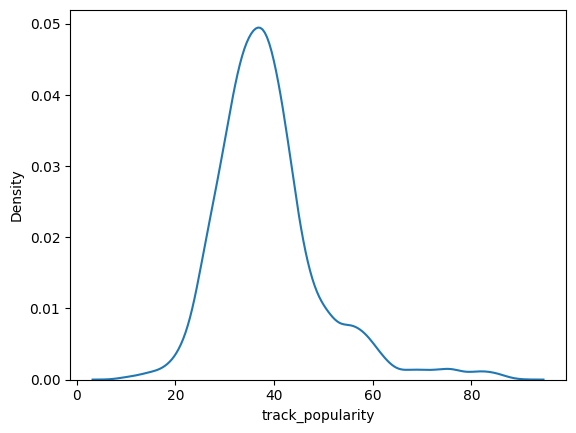

In [ ]:
sns.kdeplot(data=submission_df_cb['track_popularity'])

Analizamos cuantas features son importantes

In [ ]:
for threshold in [0.0, 0.1, 0.25, 0.5]:
    features_kept = fi_pct[fi_pct > threshold].index.tolist()

    # Identify which of the kept features are categorical
    current_cat_features = [f for f in features_kept if f in cat_features]

    m = CatBoostRegressor(iterations=1000, learning_rate=0.025,
                          early_stopping_rounds=50, random_seed=42, verbose=0)
    m.fit(X_train_dev[features_kept], y_train_dev,
          eval_set=(X_train_val[features_kept], y_train_val),
          cat_features=current_cat_features) # Pass the subset of categorical features

    pred = m.predict(X_train_val[features_kept])
    rmse = np.sqrt(mean_squared_error(y_train_val, pred))
    print(f"Threshold {threshold}% | Features: {len(features_kept):3d} | RMSE val: {rmse:.4f}")

Threshold 0.0% | Features:  85 | RMSE val: 17.6965
Threshold 0.1% | Features:  78 | RMSE val: 17.6924
Threshold 0.25% | Features:  37 | RMSE val: 17.5998
Threshold 0.5% | Features:  14 | RMSE val: 17.5227


In [ ]:
for threshold in [0.5, 0.75, 1.0, 1.5, 2.0, 3.0]:
    features_kept = fi_pct[fi_pct > threshold].index.tolist()

    current_cat_features = [f for f in features_kept if f in cat_features]

    m = CatBoostRegressor(iterations=1000, learning_rate=0.025,
                          early_stopping_rounds=50, random_seed=42, verbose=0)
    m.fit(X_train_dev[features_kept], y_train_dev,
          eval_set=(X_train_val[features_kept], y_train_val),
          cat_features=current_cat_features)

    pred = m.predict(X_train_val[features_kept])
    rmse = np.sqrt(mean_squared_error(y_train_val, pred))
    print(f"Threshold {threshold}% | Features: {len(features_kept):3d} | RMSE val: {rmse:.4f}")

Threshold 0.5% | Features:  14 | RMSE val: 17.5227
Threshold 0.75% | Features:  10 | RMSE val: 17.5524
Threshold 1.0% | Features:   9 | RMSE val: 17.6180
Threshold 1.5% | Features:   9 | RMSE val: 17.6180
Threshold 2.0% | Features:   8 | RMSE val: 17.7336
Threshold 3.0% | Features:   6 | RMSE val: 17.9537


Valores unicos de las variables

In [ ]:
print('Cantidad de valores unicos de cada columna categorica:')
for i in df[cat_features].columns:
    print(f'{i}: {df[i].nunique()} valores unicos')

Cantidad de valores unicos de cada columna categorica:
playlist_genre: 5 valores unicos
playlist_subgenre: 20 valores unicos
grupo_anio: 11 valores unicos
track_id: 22991 valores unicos
track_name: 19269 valores unicos
track_artist: 8786 valores unicos
track_album_id: 17814 valores unicos
track_album_name: 15961 valores unicos
key: 12 valores unicos
mode: 2 valores unicos
tonality: 24 valores unicos
most_extreme_feature: 9 valores unicos


In [ ]:
cols_a_eliminar = ['track_id', 'track_name', 'track_artist','track_album_id', 'track_album_name', 'playlist_genre', 'playlist_subgenre']

X_train_dev_clean = X_train_dev.drop(columns=cols_a_eliminar)
X_train_val_clean = X_train_val.drop(columns=cols_a_eliminar)
X_test_clean = X_test.drop(columns=cols_a_eliminar)

In [ ]:
current_cat_features = [f for f in X_train_dev_clean if f in cat_features]

model_clean = CatBoostRegressor(
    iterations=1000, learning_rate=0.025,
    early_stopping_rounds=50, random_seed=42, verbose=0
)
model_clean.fit(X_train_dev_clean, y_train_dev,
                eval_set=(X_train_val_clean, y_train_val),
                cat_features=current_cat_features)

fi_clean = pd.Series(
    model_clean.get_feature_importance(),
    index=X_train_dev_clean.columns
).sort_values(ascending=False)

fi_pct_clean = (fi_clean / fi_clean.sum() * 100).round(3)
fi_pct_clean

,0
track_age,11.865
grupo_anio,10.543
len_playlist_name,6.772
radio_friendly,1.939
global_atipicality,1.927
...,...
liveness,0.398
valence_sqrt,0.362
valence_sq,0.290
mode,0.278


In [ ]:
pd.DataFrame(fi_pct_clean).T

,track_age,grupo_anio,len_playlist_name,radio_friendly,global_atipicality,distance_sq_mean_duration_ms,distance_sq_mean_loudness,distance_mean_loudness,tonality,loudness_abs_sq,mood_complexity,max_z_score,distance_sq_mean_acousticness,dance_energy,distance_sq_mean_speechiness,z_loudness,distance_sq_mean_tempo,chill_score,happy_energy,loudness_abs_sqrt,distance_sq_mean_energy,loudness_abs,distance_mean_tempo,most_extreme_feature,dance_val_tension,loudness,acoustic_instr,spoken_word,distance_sq_mean_liveness,z_energy,z_tempo,melancholy_score,distance_mean_energy,distance_sq_mean_valence,live_vocal,tempo,energy,vocal_presence,studio_clean,distance_sq_mean_danceability,club_score,energy_sqrt,pure_instrumental,duration_ms,z_instrumentalness,log_instrumentalness,z_danceability,speechiness,distance_mean_acousticness,log_speechiness,acousticness,distance_mean_duration_ms,duration_min,key,instrumentalness,distance_mean_speechiness,danceability_sq,danceability_sqrt,log_duration_ms,z_speechiness,energy_sq,acoustic_contrast,z_duration_ms,danceability,distance_mean_danceability,distance_mean_liveness,dynamic_compression,loudness_energy_ratio,mood_score,log_liveness,z_acousticness,distance_mean_valence,z_valence,liveness,valence_sqrt,valence_sq,mode,valence
0,11.865,10.543,6.772,1.939,1.927,1.805,1.766,1.675,1.663,1.584,1.558,1.468,1.457,1.427,1.418,1.354,1.327,1.316,1.278,1.267,1.23,1.209,1.16,1.16,1.159,1.133,1.116,1.102,1.064,1.055,1.05,1.038,1.037,1.021,1.012,0.991,0.978,0.969,0.946,0.934,0.934,0.904,0.868,0.838,0.828,0.82,0.777,0.759,0.759,0.72,0.709,0.708,0.701,0.686,0.672,0.669,0.668,0.654,0.64,0.638,0.619,0.606,0.577,0.552,0.548,0.529,0.518,0.511,0.483,0.448,0.448,0.435,0.403,0.398,0.362,0.29,0.278,0.268


In [ ]:
for threshold in [0.0, 0.5, 0.75, 1, 1.5]:
    features_kept = fi_pct_clean[fi_pct_clean > threshold].index.tolist()

    # Identify which of the kept features are categorical
    current_cat_features = [f for f in features_kept if f in cat_features]

    m = CatBoostRegressor(iterations=1000, learning_rate=0.025,
                          early_stopping_rounds=50, random_seed=42, verbose=0)
    m.fit(X_train_dev[features_kept], y_train_dev,
          eval_set=(X_train_val[features_kept], y_train_val),
          cat_features=current_cat_features) # Pass the subset of categorical features

    rmse_dev = np.sqrt(mean_squared_error(y_train_dev, m.predict(X_train_dev[features_kept])))
    rmse_val = np.sqrt(mean_squared_error(y_train_val, m.predict(X_train_val[features_kept])))
    rmse_test = np.sqrt(mean_squared_error(y_test, m.predict(X_test[features_kept])))
    print(f"Threshold {threshold}% | Features: {len(features_kept):3d} | RMSE dev: {rmse_dev:.4f} | RMSE val: {rmse_val:.4f} | RMSE test: {rmse_test:.4f}")

Threshold 0.0% | Features:  78 | RMSE dev: 20.2262 | RMSE val: 22.1561 | RMSE test: 22.4760
Threshold 0.5% | Features:  68 | RMSE dev: 20.2221 | RMSE val: 22.1376 | RMSE test: 22.4771
Threshold 0.75% | Features:  49 | RMSE dev: 20.1784 | RMSE val: 22.1499 | RMSE test: 22.4660
Threshold 1% | Features:  35 | RMSE dev: 20.2590 | RMSE val: 22.1717 | RMSE test: 22.5643
Threshold 1.5% | Features:  11 | RMSE dev: 21.4995 | RMSE val: 22.7105 | RMSE test: 22.9791


### Rotation Forest con FE

In [ ]:
!pip install aeon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 42.1 MB/s eta 0:00:00


In [ ]:
dummies_genre = pd.get_dummies(df['playlist_genre']).astype(int)
dummies_subgenre = pd.get_dummies(df['playlist_subgenre']).astype(int)
dummies_grupo_anio = pd.get_dummies(df['grupo_anio']).astype(int)
df_wdummies = pd.concat([df[continuas], dummies_genre[['r&b']], dummies_subgenre[['neo soul']], dummies_grupo_anio], axis=1)

X_rfr = df_wdummies.copy()
y_rfr = df['track_popularity'].copy()

X_rfr_train, X_rfr_test, y_rfr_train, y_rfr_test = train_test_split(X_rfr, y_rfr, test_size=0.2, random_state=42)
X_rfr_train.columns = X_rfr_train.columns.astype(str)
X_rfr_test.columns = X_rfr_test.columns.astype(str)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from aeon.regression.sklearn import RotationForestRegressor
from sklearn.preprocessing import QuantileTransformer, PowerTransformer

# preprocesador_avanzado = ColumnTransformer(
#     transformers=[
#         # Convierte las variables a una distribución normal, reduciendo el impacto de outliers
#         # y ayudando al PCA a encontrar mejores componentes estables.
#         ('transformacion_no_lineal', QuantileTransformer(output_distribution='normal', random_state=42), continuas)
#     ],
#     remainder='passthrough'
# )

# Probá con PowerTransformer en vez de QuantileTransformer
# Es más suave y generaliza mejor
preprocesador_avanzado = ColumnTransformer(
    transformers=[
        ('transformacion_no_lineal', PowerTransformer(method='yeo-johnson'), continuas)
    ],
    remainder='passthrough'
)

# pipeline_avanzado = Pipeline([
#     ('preprocesamiento', preprocesador_avanzado),
#     ('rotation_forest', RotationForestRegressor(n_estimators=100, random_state=42))
# ])

pipeline_avanzado = Pipeline([
    ('preprocesamiento', preprocesador_avanzado),
    ('rotation_forest', RotationForestRegressor(
    n_estimators=200,
    min_group=3,
    max_group=6,        # más flexible que 10
    remove_proportion=0.5,  # volvé al default
    base_estimator=DecisionTreeRegressor(
        max_depth=10,       # más profundidad que 6
        min_samples_leaf=5, # menos restrictivo que 10
        random_state=42
    ),
    random_state=42,
    n_jobs=-1
))
])

# Ahora entrenás este objeto contenedor
pipeline_avanzado.fit(X_rfr_train, y_train)

print('Prediccion TRAIN')
y_train_pred_pipeline_final = pipeline_avanzado.predict(X_rfr_train)
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_train, y_train_pred_pipeline_final):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_train, y_train_pred_pipeline_final)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_train, y_train_pred_pipeline_final):.4f}")

print('Prediccion TEST')
y_pred_pipeline_final = pipeline_avanzado.predict(X_rfr_test)
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred_pipeline_final):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred_pipeline_final)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_test, y_pred_pipeline_final):.4f}")

Prediccion TRAIN
Error Cuadrático Medio (MSE): 342.5275
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 18.5075
Coeficiente de Determinación (R²): 0.4506
Prediccion TEST
Error Cuadrático Medio (MSE): 489.4305
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 22.1231
Coeficiente de Determinación (R²): 0.2205


In [ ]:
import time

start = time.time()
pipeline_avanzado.predict(X_rfr_test)
elapsed = time.time() - start
print(f"Tiempo de predict: {elapsed:.2f} segundos")

print(f"Estimado n_repeats=10: {730 * elapsed / 60:.1f} minutos")
print(f"Estimado n_repeats=3:  {219 * elapsed / 60:.1f} minutos")
print(f"Estimado muestra 500, n_repeats=3: {219 * elapsed * (500/len(X_test)) / 60:.1f} minutos")

Tiempo de predict: 2.49 segundos
Estimado n_repeats=10: 30.3 minutos
Estimado n_repeats=3:  9.1 minutos
Estimado muestra 500, n_repeats=3: 0.9 minutos


In [ ]:
print(f"Estimado muestra 2000, n_repeats=6: {219*2* elapsed * (2500/len(X_test)) / 60:.1f} minutos")

Estimado muestra 2000, n_repeats=6: 8.6 minutos


2019                      0.066913
track_age                 0.036001
len_playlist_name         0.026193
2000                      0.021133
r&b                       0.015029
distance_mean_loudness    0.009996
energy_sqrt               0.009731
energy_sq                 0.009730
z_energy                  0.009309
dynamic_compression       0.009208
loudness                  0.009098
z_loudness                0.009009
energy                    0.008856
loudness_abs_sqrt         0.008783
loudness_abs              0.008555
2018                      0.008489
distance_mean_energy      0.008082
loudness_energy_ratio     0.007259
loudness_abs_sq           0.006516
2010                      0.006403
dtype: float64


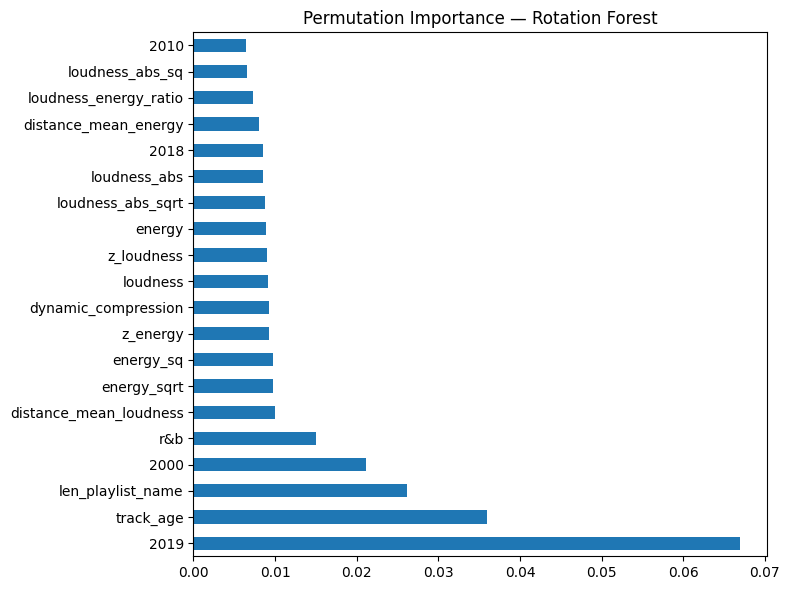

In [ ]:
from sklearn.inspection import permutation_importance

X_test_sample = X_rfr_test.sample(2500, random_state=42)
y_test_sample  = y_test[X_test_sample.index]

result = permutation_importance(
    pipeline_avanzado,
    X_test_sample,
    y_test_sample,
    n_repeats=6,
    random_state=42,
    n_jobs=-1
)

fi = pd.Series(
    result.importances_mean,
    index=X_rfr_test.columns
).sort_values(ascending=False)

print(fi.head(20))

fi.head(20).plot(kind='barh', figsize=(8, 6))
plt.title('Permutation Importance — Rotation Forest')
plt.tight_layout()
plt.show()

In [ ]:
fi[fi>0.004].shape

(34,)

In [ ]:
fi.shape

(86,)

In [ ]:
features_importantes = fi[fi > 0.005].index.tolist()
print(f"Features seleccionadas: {len(features_importantes)}")
print(features_importantes)

Features seleccionadas: 25
['2019', 'track_age', 'len_playlist_name', '2000', 'r&b', 'distance_mean_loudness', 'energy_sqrt', 'energy_sq', 'z_energy', 'dynamic_compression', 'loudness', 'z_loudness', 'energy', 'loudness_abs_sqrt', 'loudness_abs', '2018', 'distance_mean_energy', 'loudness_energy_ratio', 'loudness_abs_sq', '2010', 'neo soul', 'radio_friendly', 'vocal_presence', 'z_speechiness', 'distance_mean_speechiness']


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from aeon.regression.sklearn import RotationForestRegressor
from sklearn.preprocessing import QuantileTransformer, PowerTransformer

new_continuas = [i for i in continuas if i in features_importantes]

# Probá con PowerTransformer en vez de QuantileTransformer
# Es más suave y generaliza mejor
preprocesador_avanzado = ColumnTransformer(
    transformers=[
        ('transformacion_no_lineal', PowerTransformer(method='yeo-johnson'), new_continuas)
    ],
    remainder='passthrough'
)

# pipeline_avanzado = Pipeline([
#     ('preprocesamiento', preprocesador_avanzado),
#     ('rotation_forest', RotationForestRegressor(n_estimators=100, random_state=42))
# ])

pipeline_avanzado = Pipeline([
    ('preprocesamiento', preprocesador_avanzado),
    ('rotation_forest', RotationForestRegressor(
    n_estimators=200,
    min_group=5,
    max_group=8,        # más flexible que 10
    remove_proportion=0.65,  # volvé al default
    # base_estimator=DecisionTreeRegressor(
    #     max_depth=10,       # más profundidad que 6
    #     min_samples_leaf=4, # menos restrictivo que 10
    #     random_state=42
    # ),
    random_state=42,
    n_jobs=-1
))
])

# Ahora entrenás este objeto contenedor
pipeline_avanzado.fit(X_rfr_train[features_importantes], y_train)

print('Prediccion TRAIN')
y_train_pred_pipeline_final = pipeline_avanzado.predict(X_rfr_train[features_importantes])
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_train, y_train_pred_pipeline_final):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_train, y_train_pred_pipeline_final)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_train, y_train_pred_pipeline_final):.4f}")

print('Prediccion TEST')
y_pred_pipeline_final = pipeline_avanzado.predict(X_rfr_test[features_importantes])
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred_pipeline_final):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred_pipeline_final)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_test, y_pred_pipeline_final):.4f}")

Prediccion TRAIN
Error Cuadrático Medio (MSE): 5.0728
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 2.2523
Coeficiente de Determinación (R²): 0.9919
Prediccion TEST
Error Cuadrático Medio (MSE): 503.1331
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 22.4306
Coeficiente de Determinación (R²): 0.1987
